## This code generated list of event times from given variable rate function (Inhomogeneous Poisson process), bins events into bins of specified size and plots binned time series

In [ ]:
# First approach does not control the time interval length

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

#  Rate function with modulation amplitude p  and frequency f 
p = 0.9
f = 0.01
rate_func = lambda t: p * np.sin(2 * np.pi * f * t) + (1-p)/(2*np.pi) + 1

# number of events to generate
num_events = 1000

# Inhomogeneous Poisson 
def generate_event_times(rate_func, num_events):
    # 1. Find a safe ceiling for the rate function
    max_rate = p  + (1 - p) / (2 * np.pi) +1
    
    events = []
    current_time = 0
    
    # 2. Loop until the specific number of events is reached
    while len(events) < num_events:
        # Generate a potential wait time based on the maximum rate
        wait_time = np.random.exponential(1 / max_rate)
        current_time += wait_time
        
        # 3. Thinning: Accept the event with probability proportional to the actual rate
        if np.random.uniform() < rate_func(current_time) / max_rate:
            events.append(current_time)
            
    return np.array(events)

    
# Generate num_events  event times using the rate function 
event_times = generate_event_times(rate_func, num_events)

# Binning with bin size of 10 
bin_size = 4
bins = np.arange(0, event_times[-1] + bin_size, bin_size)
hist, bin_edges = np.histogram(event_times, bins=bins)

# Plotting the histogram for the corrected event times
plt.figure(figsize=(10, 6))
plt.bar(range(len(hist)), hist, width=1, edgecolor='black')
plt.xlabel('Bin Number')
plt.ylabel('Number of Events')
plt.title('Corrected: Number of Events in Each Bin vs. Bin Number (1000 Events, p=0.9)')
plt.show()


In [31]:
len(event_times)

1000

In [38]:
event_times[-1]

499.9550515932516

In [ ]:
# This approach allows to specify both the interval length and number of events

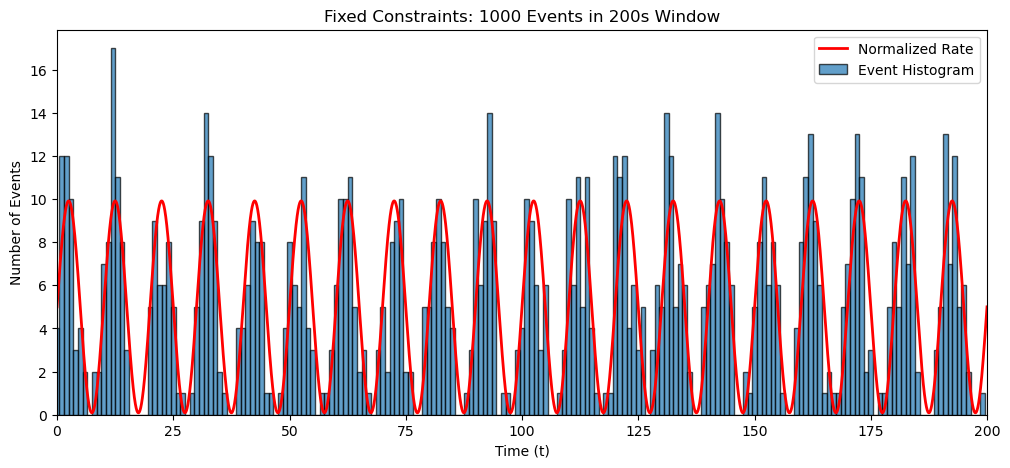

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
p = 0.9
f = 0.1
T = 200        
num_events = 1000 
offset = (1-p)/(2*np.pi)
t_vals = np.linspace(0, T, 10000) # Defined globally to fix the error

r_shape = lambda t: p * (np.sin(2 * np.pi * f * t) + 1) + offset

def generate_fixed_n_t(shape_func, T, N):
    # Use the global t_vals or create a local one for sampling
    max_val = np.max(shape_func(t_vals))
    
    events = []
    while len(events) < N:
        t_propose = np.random.uniform(0, T)
        h_propose = np.random.uniform(0, max_val)
        
        if h_propose < shape_func(t_propose):
            events.append(t_propose)
            
    return np.sort(np.array(events))

event_times = generate_fixed_n_t(r_shape, T, num_events)

# --- Visualization ---
bin_size = 1.0 
bins = np.arange(0, T + bin_size, bin_size)
hist, bin_edges = np.histogram(event_times, bins=bins)

plt.figure(figsize=(12, 5))
plt.bar(bin_edges[:-1], hist, width=bin_size, edgecolor='black', alpha=0.7, label='Event Histogram')

# Fixed scaling factor for normalization
integral = (p + offset) * T + (p / (2 * np.pi * f)) * (1 - np.cos(2 * np.pi * f * T))
scaling_factor = num_events / integral

plt.plot(t_vals, r_shape(t_vals) * scaling_factor * bin_size, color='red', lw=2, label='Normalized Rate')

plt.xlim(0, T)
plt.xlabel('Time (t)')
plt.ylabel('Number of Events')
plt.title(f'Fixed Constraints: {num_events} Events in {T}s Window')
plt.legend()
plt.show()
